In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import igraph as ig
import matplotlib.pyplot as plt
import pickle

In [5]:
GRAPHS = {"invariant": "/homes/shahashka/lucid_cd/data/rpe1_experiment2/bootstrap_graphs3/dag_gnn_combined.gexf",
          "F":"/homes/shahashka/lucid_cd/data/rpe1_experiment2/bootstrap_graphs2/dag_gnn_full_doseF.gexf",
          "G":"/homes/shahashka/lucid_cd/data/rpe1_experiment2/bootstrap_graphs2/dag_gnn_full_doseG.gexf",
          "H":"/homes/shahashka/lucid_cd/data/rpe1_experiment2/bootstrap_graphs2/dag_gnn_full_doseH.gexf",
          "I":"/homes/shahashka/lucid_cd/data/rpe1_experiment2/bootstrap_graphs2/dag_gnn_full_doseI.gexf",
          "J":"/homes/shahashka/lucid_cd/data/rpe1_experiment2/bootstrap_graphs2/dag_gnn_full_doseJ.gexf" 
          }
with open("/homes/shahashka/lucid_cd/data/gene_groups.pkl", "rb") as f:
    CAUSAL_TFS, CAUSAL_NEIGHBORHOODS, KOSMOS, CHATGPT, BNL = pickle.load(f)

In [ ]:
for name, file in GRAPHS.items():
    print(name)
    G = nx.read_gexf(file)
    print(len(G.nodes()))
    if name == 'invariant':
        G = nx.subgraph(G, CAUSAL_NEIGHBORHOODS["all_doses_dose_rate"])
    else:
        G = nx.subgraph(G, CAUSAL_NEIGHBORHOODS[name])
    scores = pd.read_csv(f"causal_landscape_scores_{name}.csv")
    # iterate through rows and attach attributes
    for _, row in scores.iterrows():

        node = row["node"]
        scope = row["scope"]
        label = row["label"]
        mean = row["mean"]

        attr_name = f"mean_{scope}_{label}"

        if node in G:
            G.nodes[node][attr_name] = float(mean)
    nx.write_gexf(G, f"scores_{name}.gexf")

invariant


In [7]:
name="H"
file = GRAPHS[name]
G = nx.read_gexf(file)
print(len(G.nodes()))
scores = pd.read_csv(f"causal_landscape_scores_{name}.csv")
# iterate through rows and attach attributes
for _, row in scores.iterrows():

    node = row["node"]
    scope = row["scope"]
    label = row["label"]
    mean = row["mean"]
    if scope.endswith("hop"):
        scope = "k_hop"

    attr_name = f"mean_{scope}_{label}"

    if node in G:
        G.nodes[node][attr_name] = float(mean)
nx.write_gexf(G, f"scores_{name}.gexf")

1053


In [35]:
import pickle
with open('feature_norm.pkl', 'rb') as file:
    features = pickle.load(file)

print(features['causal_H_recursive_dose_rate'])
print(features['causal_H_recursive_week'])

KeyError: 'causal_H_recursive_dose_rate'

In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

dose_rates = [0.0, 0.004, 0.04, 0.4, 4.0, 8.0]
dose_rate_name = ["F", "G", "H", "I", "J"]
#colors = ['black', 'red', 'orange', 'green', 'blue', 'purple']
colors = ['black', 'red', 'red', 'red', 'blue', 'purple']

weeks = np.arange(1,10)
color_map = dict(zip(dose_rates, colors))

log2fold_df = pd.read_csv(f"/homes/shahashka/lucid_cd/data/rpe1_experiment2/rpe1_9week_study_experiment2_diffexp_deseq_vs_control_all_dG_W2_adjust.txt", sep="\t")
# log2fold_df = log2fold_df.loc[log2fold_df['padj'] < 0.05] # This is new, I think I should filter by p value. However this means there are no genes that DE across all dose rates
# log2fold_df = log2fold_df.loc[abs(log2fold_df['log2FoldChange']) > 1]
# print(log2fold_df.shape)

log2fold_df = log2fold_df.groupby(["Dose", "Week", "Gene"]).mean(numeric_only=True)

log2fold_df = log2fold_df["log2FoldChange"].unstack(level='Gene')
#log2fold_df = log2fold_df.fillna(0)
log2fold_df = log2fold_df.dropna(axis=1)
log2fold_df = log2fold_df.reset_index()
log2fold_df = log2fold_df.rename(columns={"Dose":"dose_rate", "Week": "week"})
dose_vector = [dose_rates[dose_rate_name.index(d[1])+1] for d in log2fold_df['dose_rate']]
week_vector = [float(w[1]) for w in log2fold_df['week']]
log2fold_df['dose_rate'] = dose_vector
log2fold_df['week'] = week_vector

norm_matrix = StandardScaler().fit_transform(log2fold_df)
log2fold_df = pd.DataFrame(data=norm_matrix, columns=log2fold_df.columns)

log2fold_df['dose_rate'] = dose_vector
log2fold_df['week'] = week_vector

tpm_df = pd.read_csv("/homes/shahashka/lucid_cd/data/rpe1_experiment2/cd_tpm_matrix_combined_dose_rate.csv", header=0)



In [31]:
print(week_vector)
print(dose_vector)
tpm_df['week']

[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
[0.004, 0.004, 0.004, 0.004, 0.004, 0.004, 0.004, 0.004, 0.004, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0]


0      4
1      5
2      2
3      8
4      9
      ..
103    6
104    3
105    8
106    9
107    7
Name: week, Length: 108, dtype: int64

In [18]:
holdout_inds = [i for i in np.arange(0,len(week_vector),5)]
# j=0
# for i in holdout_inds:
#     print(week_vector[i])
#     print(dose_vector[i])

print(np.array(week_vector)[holdout_inds])
print(np.array(dose_vector)[holdout_inds])
print(holdout_inds)

[1. 6. 2. 7. 3. 8. 4. 9. 5.]
[4.e-03 4.e-03 4.e-02 4.e-02 4.e-01 4.e-01 4.e+00 4.e+00 8.e+00]
[0, 5, 10, 15, 20, 25, 30, 35, 40]


/homes/shahashka/.conda/envs/lucid_cd/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/homes/shahashka/.conda/envs/lucid_cd/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


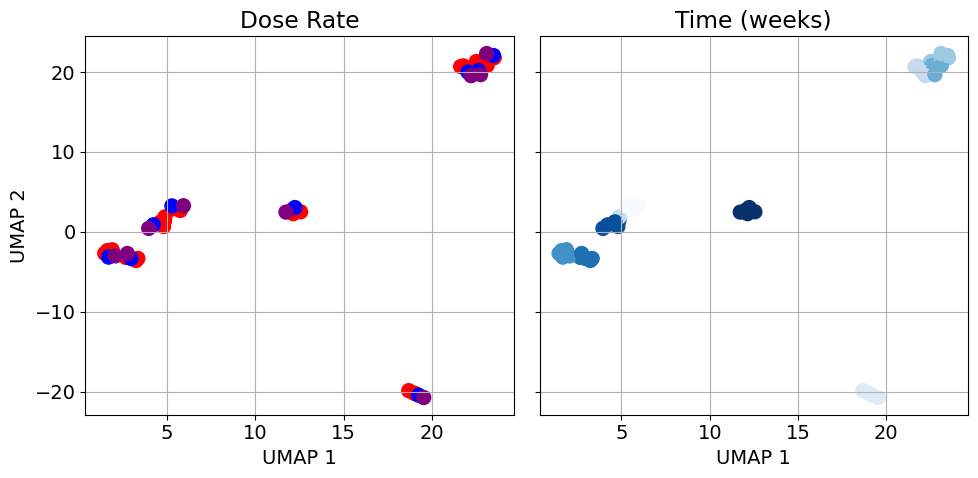

In [57]:
from math import log
import matplotlib as mpl
import umap
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
reducer = umap.UMAP(n_neighbors=5, min_dist=0.3, metric='euclidean', random_state=42)

mpl.rcParams['font.size'] = 14
fig, axs = plt.subplots(1,2, sharey=True, figsize=(10,5))
#genes = log2fold_df_na.columns.drop(["dose_rate", "week"])
# genes = [f for f in features['elastic_week'] if f in log2fold_df.columns]
genes = [f for f in classes[0] if f in log2fold_df.columns]
embedding_2d = reducer.fit_transform(log2fold_df[genes])
pca_2d = pca.fit_transform(log2fold_df[genes])

# genes = [f for f in classes[0] if f in tpm_df.columns]
# embedding_2d = reducer.fit_transform(tpm_df[genes])
# pca_2d = pca.fit_transform(tpm_df[genes])

# kmeans = KMeans(n_clusters=3)
# cluster_ids = kmeans.fit_predict(embedding_2d)

axs[0].scatter(embedding_2d[:,0], embedding_2d[:,1],c=[color_map[dr] for dr in log2fold_df['dose_rate']],s=100, label='Dose Rate') # alpha=df['week']/10,
axs[1].scatter(embedding_2d[:,0], embedding_2d[:,1], c=log2fold_df['week'], cmap='Blues', s=100,label='Time (weeks)')

# axs[0].scatter(pca_2d[:,0], pca_2d[:,1],c=[color_map[dr] for dr in log2fold_df['dose_rate']],s=100, label='Dose Rate') # alpha=df['week']/10,
# axs[1].scatter(pca_2d[:,0], pca_2d[:,1], c=log2fold_df['week'], cmap='Blues', s=100,label='Time (weeks)')

axs[0].set_title('Dose Rate')
axs[1].set_title('Time (weeks)')
for ax in axs:
    ax.set_xlabel("UMAP 1")
    ax.grid(True)
axs[0].set_ylabel("UMAP 2")
plt.tight_layout()
plt.show()

In [16]:
with open("multi_task_elastic_net_coefs_ai_kosmos.pkl", "rb") as f:
    data = pickle.load(f)
print(data.keys())
features = np.array(data['features'])

dict_keys(['features', 'dose_rate', 'week'])


In [17]:
classes = []
for coef in data['week']['coef']:
    print(len(coef))
    print(len(np.argwhere(np.array(coef)!=0)))
    significant_inds = [i[0] for i in np.argwhere(np.array(coef)!=0)]
    print(features[significant_inds])
    classes.append(features[significant_inds])
classes[0] == classes[1]

71
40
['PDE11A' 'PHACTR4' 'PKP2' 'INSC' 'EGR1' 'PDE3A' 'ID1' 'SNAI2' 'SREBF1'
 'RFWD3' 'ADAMTS1' 'ZEB2' 'POSTN' 'CRMP1' 'IBSP' 'PLPP3' 'RSPO3' 'TWIST1'
 'P2RX5' 'PLEKHA7' 'ZNF516' 'PDE4B' 'CXCL1' 'PDE2A' 'TBX18' 'CD274' 'ZEB1'
 'FERMT1' 'ERBB4' 'CXCL8' 'PLXNA4' 'LOX' 'TFRC' 'COL1A1' 'TGFBI' 'FOS'
 'COL14A1' 'PIK3IP1' 'HTR1D' 'ADGRF1']
71
40
['PDE11A' 'PHACTR4' 'PKP2' 'INSC' 'EGR1' 'PDE3A' 'ID1' 'SNAI2' 'SREBF1'
 'RFWD3' 'ADAMTS1' 'ZEB2' 'POSTN' 'CRMP1' 'IBSP' 'PLPP3' 'RSPO3' 'TWIST1'
 'P2RX5' 'PLEKHA7' 'ZNF516' 'PDE4B' 'CXCL1' 'PDE2A' 'TBX18' 'CD274' 'ZEB1'
 'FERMT1' 'ERBB4' 'CXCL8' 'PLXNA4' 'LOX' 'TFRC' 'COL1A1' 'TGFBI' 'FOS'
 'COL14A1' 'PIK3IP1' 'HTR1D' 'ADGRF1']
71
40
['PDE11A' 'PHACTR4' 'PKP2' 'INSC' 'EGR1' 'PDE3A' 'ID1' 'SNAI2' 'SREBF1'
 'RFWD3' 'ADAMTS1' 'ZEB2' 'POSTN' 'CRMP1' 'IBSP' 'PLPP3' 'RSPO3' 'TWIST1'
 'P2RX5' 'PLEKHA7' 'ZNF516' 'PDE4B' 'CXCL1' 'PDE2A' 'TBX18' 'CD274' 'ZEB1'
 'FERMT1' 'ERBB4' 'CXCL8' 'PLXNA4' 'LOX' 'TFRC' 'COL1A1' 'TGFBI' 'FOS'
 'COL14A1' 'PIK3IP1' 'HTR1D'

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True])

In [ ]:
with open("features/logistic_regression_dose_rate_causal_F.pkl", "rb") as f:
    data = pickle.load(f)
print(data.keys())
features = np.array(data['features'])
classes = []
for coef in data['dose_rate']['coef']:
    print(len(coef))
    print(len(np.argwhere(np.array(coef)!=0)))
    significant_inds = [i[0] for i in np.argwhere(np.array(coef)!=0)]
    print(features[significant_inds])
    classes.append(features[significant_inds])


dict_keys(['features', 'dose_rate'])
61
7
['UBB' 'MCL1' 'CFL1' 'CCND1' 'CRYAB' 'HSP90AA1' 'GPR157']
61
4
['HLA-C' 'FTL' 'TAGLN' 'MYC']
61
3
['STUB1' 'S100A6' 'UBC']


ValueError: operands could not be broadcast together with shapes (7,) (4,) 